In [1]:
!pip install sentence-transformers

In [2]:
text_data = [
    # Cricket (4)
    "Virat Kohli scored a brilliant century in the match",
    "Jasprit Bumrah took three wickets with his fast bowling",
    "Rohit Sharma hit multiple boundaries in the powerplay",
    "MS Dhoni finished the game with a six in the final over",

    # Cooking (Chef Competition - 3)
    "The chef impressed the judges with a creative dish in the competition",
    "Contestants prepared unique recipes under time pressure in the cooking contest",
    "The final round required chefs to present visually appealing gourmet meals",

    # Cybersecurity (3)
    "Cyber attacks can compromise sensitive user data",
    "Using strong passwords helps protect online accounts",
    "Encryption is used to safeguard confidential information"
]

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(text_data)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
vectors = model.encode(text_data)
print("Vector shape:", vectors.shape)

Vector shape: (10, 384)


In [6]:
sim_scores = cosine_similarity(vectors)

print("Similarity Matrix:\n")
print(sim_scores)

Similarity Matrix:

[[ 1.0000000e+00  3.9021176e-01  4.0477952e-01  3.9532304e-01
   1.8204337e-01  1.1827333e-01  1.8735810e-01  1.1059332e-01
   3.2921892e-02  7.1821705e-02]
 [ 3.9021176e-01  1.0000004e+00  3.9380568e-01  2.8936103e-01
   1.2637280e-01  5.3082831e-02  8.1387624e-02  1.2776062e-01
  -1.2500441e-02 -2.8920919e-04]
 [ 4.0477952e-01  3.9380568e-01  9.9999988e-01  3.5225892e-01
   9.9491931e-02  9.3383178e-02  9.9458143e-02  1.8427354e-01
   8.3229624e-02  6.4884275e-03]
 [ 3.9532304e-01  2.8936103e-01  3.5225892e-01  1.0000001e+00
   1.7725223e-01  1.4472738e-01  1.7688584e-01  5.5329606e-02
  -5.9271961e-02 -3.2315109e-02]
 [ 1.8204337e-01  1.2637280e-01  9.9491931e-02  1.7725223e-01
   1.0000001e+00  6.3120222e-01  5.2934378e-01 -3.6598146e-02
  -6.8487994e-02 -1.3517054e-02]
 [ 1.1827333e-01  5.3082831e-02  9.3383178e-02  1.4472738e-01
   6.3120222e-01  9.9999964e-01  5.1463139e-01  5.2831206e-02
  -9.7659836e-03  4.9128316e-02]
 [ 1.8735810e-01  8.1387624e-02  9.945

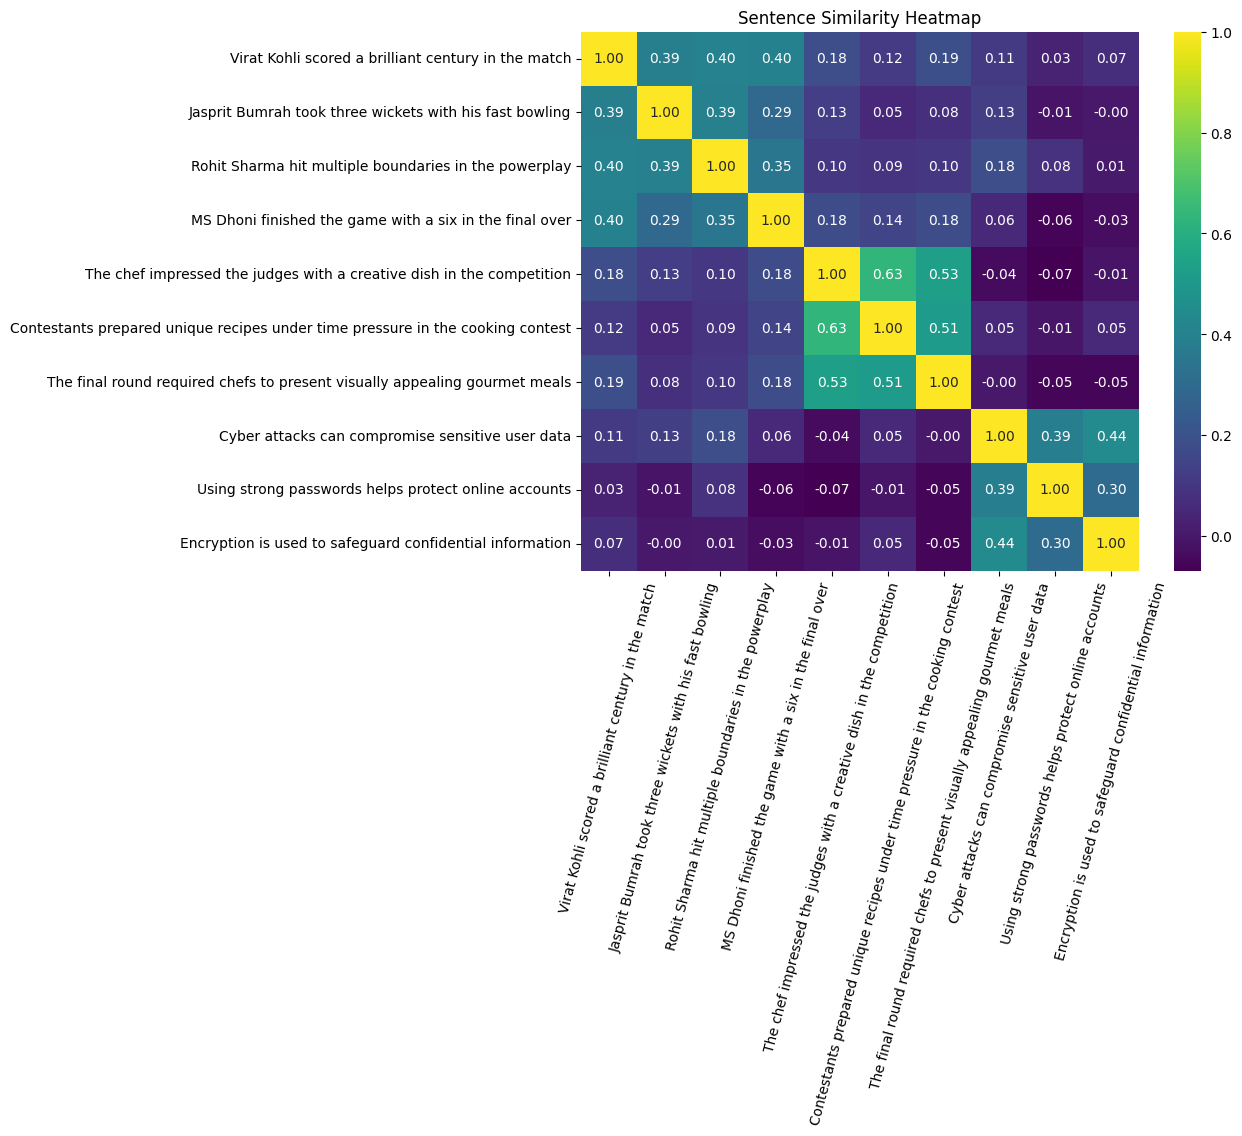

In [7]:
plt.figure(figsize=(9,7))

sns.heatmap(sim_scores,
            annot=True,
            fmt=".2f",
            cmap="viridis",   # different color from your version
            xticklabels=text_data,
            yticklabels=text_data)

plt.title("Sentence Similarity Heatmap")
plt.xticks(rotation=75)   # slightly different angle
plt.yticks(rotation=0)

plt.show()

In [8]:
query_text = "The bowler took three wickets in one over"

query_vector = model.encode([query_text])

similarity_values = cosine_similarity(query_vector, vectors)[0]

top_results = similarity_values.argsort()[-2:][::-1]

print("Query Sentence:", query_text)
print("\nMost Similar Sentences:\n")

for i in top_results:
    print(text_data[i])
    print("Score:", similarity_values[i])
    print()

Query Sentence: The bowler took three wickets in one over

Most Similar Sentences:

Jasprit Bumrah took three wickets with his fast bowling
Score: 0.6667439

Virat Kohli scored a brilliant century in the match
Score: 0.44090635

